In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [8]:
train_dir = "../data/processed/train"
val_dir = "../data/processed/val"
test_dir = "../data/processed/test"

In [9]:
train_transforms = transforms.Compose([
    
    transforms.Resize((224, 224)),
    
    transforms.RandomHorizontalFlip(),
    
    transforms.RandomRotation(10),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [10]:
val_test_transforms = transforms.Compose([
    
    transforms.Resize((224, 224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [11]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=val_test_transforms
)

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [14]:
class BrainTumorCNN(nn.Module):
    
    def __init__(self):
        
        super(BrainTumorCNN, self).__init__()
        
        self.features = nn.Sequential(
            
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        
        self.classifier = nn.Sequential(
            
            nn.Flatten(),
            
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            
            nn.Linear(512, 4)
        )
    
    
    def forward(self, x):
        
        x = self.features(x)
        
        x = self.classifier(x)
        
        return x

In [16]:
model = BrainTumorCNN().to(device)

print(model)

BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=4, bias=True)
  )
)


In [17]:
criterion = nn.CrossEntropyLoss()

In [18]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [19]:
num_epochs = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [20]:
for epoch in range(num_epochs):
    
    # TRAINING
    
    model.train()
    
    running_loss = 0
    correct = 0
    total = 0
    
    
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        
        optimizer.zero_grad()
        
        
        outputs = model(images)
        
        
        loss = criterion(outputs, labels)
        
        
        loss.backward()
        
        
        optimizer.step()
        
        
        running_loss += loss.item()
        
        
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        
        correct += (predicted == labels).sum().item()
    
    
    train_loss = running_loss / len(train_loader)
    
    train_accuracy = 100 * correct / total
    
    
    train_losses.append(train_loss)
    
    train_accuracies.append(train_accuracy)
    
    
    # VALIDATION
    
    model.eval()
    
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    
    with torch.no_grad():
        
        for images, labels in val_loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            
            val_loss += loss.item()
            
            
            _, predicted = torch.max(outputs, 1)
            
            val_total += labels.size(0)
            
            val_correct += (predicted == labels).sum().item()
    
    
    val_loss /= len(val_loader)
    
    val_accuracy = 100 * val_correct / val_total
    
    
    val_losses.append(val_loss)
    
    val_accuracies.append(val_accuracy)
    
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
    
    print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")
    
    print("-" * 50)

Epoch [1/10]
Train Loss: 0.8204 | Train Accuracy: 69.35%
Val Loss: 0.5062 | Val Accuracy: 80.45%
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.4521 | Train Accuracy: 82.70%
Val Loss: 0.4137 | Val Accuracy: 85.71%
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.3088 | Train Accuracy: 88.86%
Val Loss: 0.3204 | Val Accuracy: 88.12%
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.2397 | Train Accuracy: 90.87%
Val Loss: 0.2398 | Val Accuracy: 91.16%
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.1654 | Train Accuracy: 93.79%
Val Loss: 0.2596 | Val Accuracy: 90.98%
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.1245 | Train Accuracy: 95.69%
Val Loss: 0.2557 | Val Accuracy: 90.89%
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.0960 | Train Accuracy: 96.65%
Val Loss: 0.2407 | Val Accuracy: 91.96%
---------------

In [24]:
print(model)

BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=4, bias=True)
  )
)


In [25]:
torch.save(
    model.state_dict(),
    "../models/baseline_cnn.pth"
)

print("Model saved successfully.")

Model saved successfully.


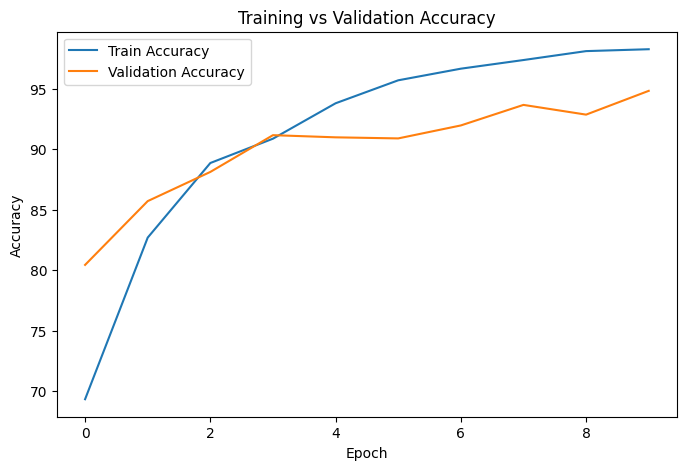

In [23]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.savefig("../results/figures/accuracy_curve.png")

plt.show()

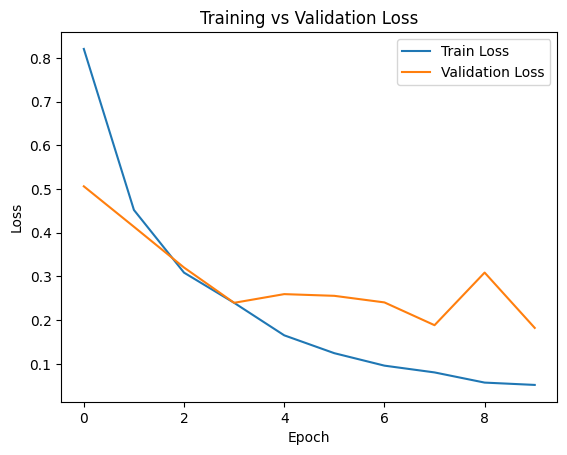

In [22]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()